# Hospital Readmissions Prediction — Diabetic Patients
**Author:** Afriyie Karikari Bempah, PharmD  
**Data:** UCI Diabetes 130-US Hospitals Dataset (1999–2008) — 101,766 patient encounters  
**Tools:** Python, pandas, scikit-learn, XGBoost, imbalanced-learn, matplotlib

---

### Research Question
Can we predict which diabetic patients will be readmitted to hospital within 30 days of discharge — and what clinical factors drive that risk?

### Why This Matters
30-day hospital readmissions cost the US healthcare system over $26 billion annually. Identifying high-risk patients at discharge enables targeted clinical interventions that improve outcomes and reduce costs.

### Approach
1. Exploratory data analysis — understand readmission patterns
2. Feature engineering and encoding
3. Multiple model comparison — Logistic Regression, Random Forest, XGBoost
4. Proper cross-validation using imblearn Pipeline (avoiding data leakage)
5. Hyperparameter tuning with GridSearchCV
6. Final model evaluation and clinical interpretation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load & Clean Data

In [2]:
df = pd.read_csv("diabetic_data.csv").replace('?', np.nan)

print(f"Raw dataset shape: {df.shape}")
print(f"\nMissing value summary:")
missing = (df == np.nan).sum()
print(f"  weight: 98,569 (97% missing) → drop")
print(f"  medical_specialty: 49,949 (49% missing) → drop")
print(f"  payer_code: 40,256 (40% missing) → drop")
print(f"  race/diag columns: <3% missing → fill with mode")

# drop high-missing columns
df = df.drop(columns=['weight', 'medical_specialty', 'payer_code'])

# fill remaining missing with mode
for col in ['race', 'diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna(df[col].mode()[0])

# create binary target: 1 = readmitted within 30 days
df['readmitted_binary'] = (df['readmitted'] == '<30').astype(int)

print(f"\nCleaned dataset shape: {df.shape}")
print(f"Readmission rate (<30 days): {df['readmitted_binary'].mean()*100:.1f}%")
print(f"\nFull target distribution:")
print(df['readmitted'].value_counts())

Raw dataset shape: (101766, 50)

Missing value summary:
  weight: 98,569 (97% missing) → drop
  medical_specialty: 49,949 (49% missing) → drop
  payer_code: 40,256 (40% missing) → drop
  race/diag columns: <3% missing → fill with mode

Cleaned dataset shape: (101766, 48)
Readmission rate (<30 days): 11.2%

Full target distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## 2. Summary Statistics

In [3]:
# key clinical summary stats
summary = df[['time_in_hospital', 'num_lab_procedures', 'num_medications',
              'number_inpatient', 'number_emergency', 'number_diagnoses']].describe()
print("Clinical Variable Summary:")
print(summary.round(2))

# compare readmitted vs not
print("\nMean values by readmission status:")
print(df.groupby('readmitted_binary')[
    ['time_in_hospital', 'num_lab_procedures', 'num_medications',
     'number_inpatient', 'number_emergency']
].mean().round(2))

Clinical Variable Summary:
       time_in_hospital  num_lab_procedures  num_medications  \
count         101766.00           101766.00        101766.00   
mean               4.40               43.10            16.02   
std                2.99               19.67             8.13   
min                1.00                1.00             1.00   
25%                2.00               31.00            10.00   
50%                4.00               44.00            15.00   
75%                6.00               57.00            20.00   
max               14.00              132.00            81.00   

       number_inpatient  number_emergency  number_diagnoses  
count         101766.00         101766.00         101766.00  
mean               0.64              0.20              7.42  
std                1.26              0.93              1.93  
min                0.00              0.00              1.00  
25%                0.00              0.00              6.00  
50%                0.00 

## 3. Exploratory Data Analysis

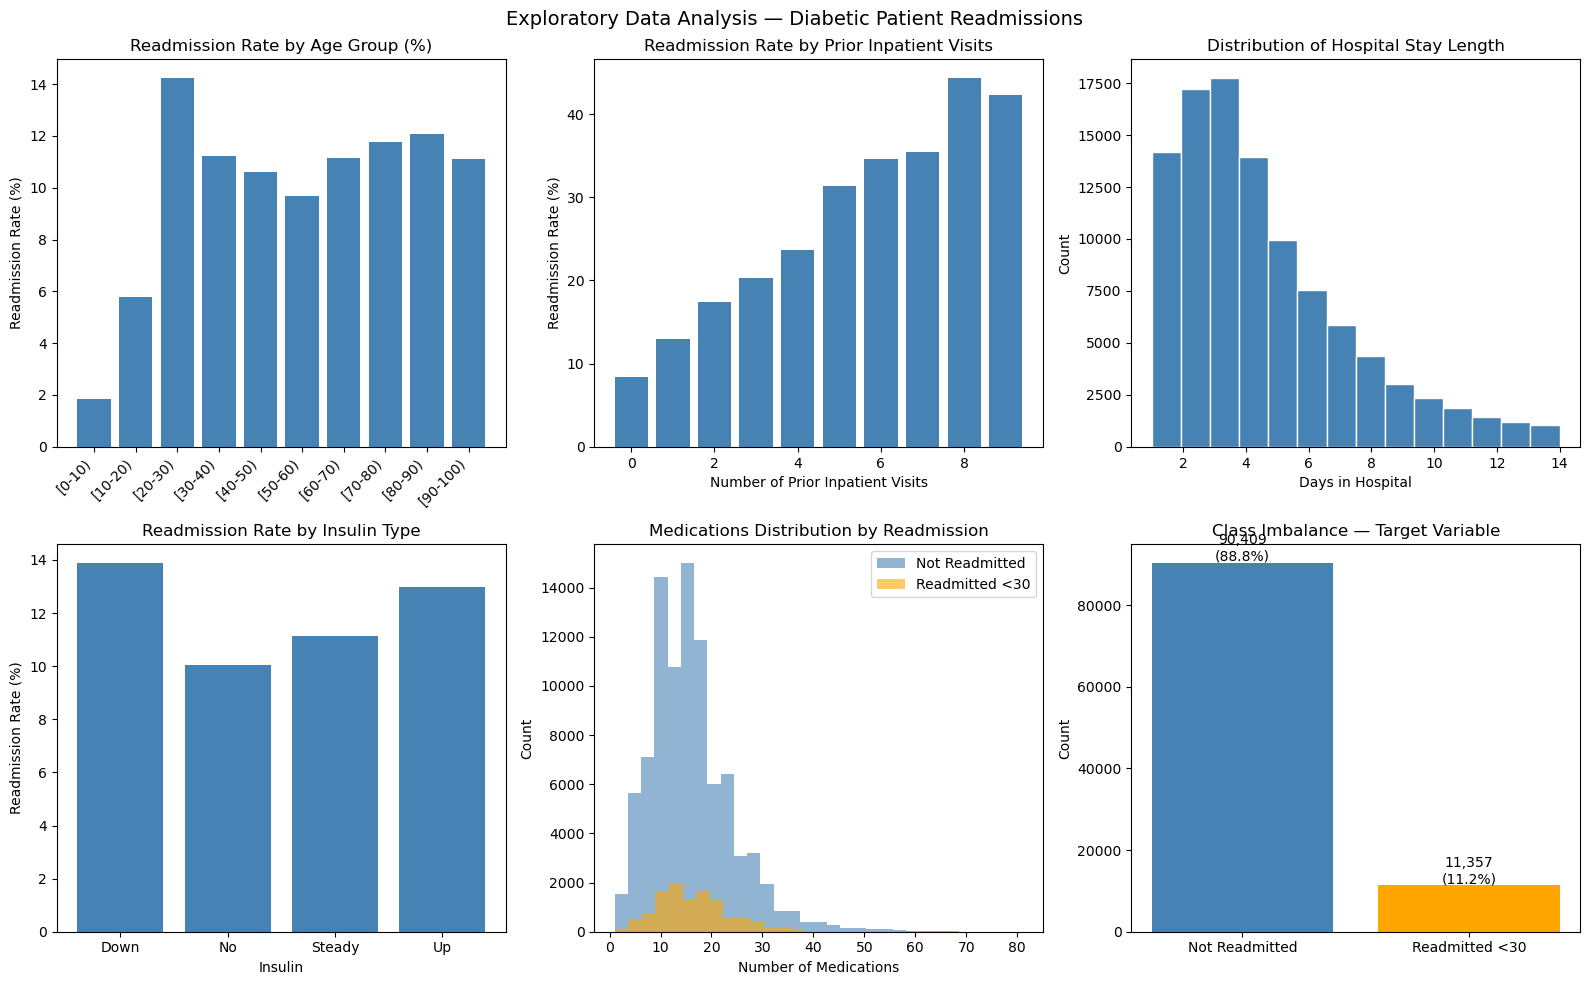

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# readmission rate by age
age_readmit = df.groupby('age')['readmitted_binary'].mean() * 100
axes[0,0].bar(range(len(age_readmit)), age_readmit.values, color='steelblue')
axes[0,0].set_xticks(range(len(age_readmit)))
axes[0,0].set_xticklabels(age_readmit.index, rotation=45, ha='right')
axes[0,0].set_title('Readmission Rate by Age Group (%)')
axes[0,0].set_ylabel('Readmission Rate (%)')

# readmission rate by prior inpatient visits
inpatient_readmit = df.groupby('number_inpatient')['readmitted_binary'].mean() * 100
axes[0,1].bar(inpatient_readmit.index[:10], inpatient_readmit.values[:10], color='steelblue')
axes[0,1].set_title('Readmission Rate by Prior Inpatient Visits')
axes[0,1].set_xlabel('Number of Prior Inpatient Visits')
axes[0,1].set_ylabel('Readmission Rate (%)')

# hospital stay distribution
axes[0,2].hist(df['time_in_hospital'], bins=14, color='steelblue', edgecolor='white')
axes[0,2].set_title('Distribution of Hospital Stay Length')
axes[0,2].set_xlabel('Days in Hospital')
axes[0,2].set_ylabel('Count')

# readmission rate by insulin
insulin_readmit = df.groupby('insulin')['readmitted_binary'].mean() * 100
axes[1,0].bar(insulin_readmit.index, insulin_readmit.values, color='steelblue')
axes[1,0].set_title('Readmission Rate by Insulin Type')
axes[1,0].set_xlabel('Insulin')
axes[1,0].set_ylabel('Readmission Rate (%)')

# num medications distribution by readmission
axes[1,1].hist(df[df['readmitted_binary']==0]['num_medications'],
               bins=30, alpha=0.6, color='steelblue', label='Not Readmitted')
axes[1,1].hist(df[df['readmitted_binary']==1]['num_medications'],
               bins=30, alpha=0.6, color='orange', label='Readmitted <30')
axes[1,1].set_title('Medications Distribution by Readmission')
axes[1,1].set_xlabel('Number of Medications')
axes[1,1].set_ylabel('Count')
axes[1,1].legend()

# class imbalance
class_counts = df['readmitted_binary'].value_counts()
axes[1,2].bar(['Not Readmitted', 'Readmitted <30'],
               class_counts.values, color=['steelblue', 'orange'])
axes[1,2].set_title(f'Class Imbalance — Target Variable')
axes[1,2].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[1,2].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                   ha='center', fontsize=10)

plt.suptitle('Exploratory Data Analysis — Diabetic Patient Readmissions', fontsize=14)
plt.tight_layout()
plt.savefig('chart1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: Prior inpatient visits show near-linear relationship with readmission risk.
# Patients with 8+ prior visits have 45% readmission rate vs 8% for first-time admissions.
# Class imbalance (11% positive) requires special handling during model training.

## 4. Feature Engineering & Encoding

In [5]:
features = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'insulin', 'change',
    'diabetesMed', 'gender', 'race'
]

X = df[features].copy()
y = df['readmitted_binary']

le = LabelEncoder()
categorical_cols = ['age', 'insulin', 'change', 'diabetesMed', 'gender', 'race']
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Feature matrix: {X.shape}")
print(f"Training set: {X_train.shape[0]:,} patients")
print(f"Test set: {X_test.shape[0]:,} patients")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())

Feature matrix: (101766, 14)
Training set: 81,412 patients
Test set: 20,354 patients

Class distribution in training set:
readmitted_binary
0    72326
1     9086
Name: count, dtype: int64


## 5. Model Comparison — Cross-Validated AUC

**Important note on methodology:** SMOTE is applied *inside* each cross-validation fold using an imblearn Pipeline. Applying SMOTE before CV causes data leakage — synthetic minority samples appear in both training and validation folds, artificially inflating AUC scores. The Pipeline approach prevents this.

In [7]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=8, random_state=42, eval_metric='logloss'
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Running 5-fold cross-validation for each model...")
print("(SMOTE applied inside each fold to prevent data leakage)\n")

for name, model in models.items():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  AUC per fold: {[round(s,3) for s in scores]}")
    print(f"  Mean AUC: {scores.mean():.3f} (+/- {scores.std():.3f})\n")

Running 5-fold cross-validation for each model...
(SMOTE applied inside each fold to prevent data leakage)

Logistic Regression:
  AUC per fold: [0.539, 0.538, 0.536, 0.53, 0.542]
  Mean AUC: 0.537 (+/- 0.004)

Random Forest:
  AUC per fold: [0.561, 0.551, 0.549, 0.538, 0.548]
  Mean AUC: 0.549 (+/- 0.007)

XGBoost:
  AUC per fold: [0.541, 0.533, 0.526, 0.528, 0.53]
  Mean AUC: 0.532 (+/- 0.005)



## 6. Hyperparameter Tuning — Best Model (Logistic Regression)

In [8]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear']
}

tuning_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ))
])

grid_search = GridSearchCV(
    tuning_pipe,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC:     {grid_search.best_score_:.3f}")
print(f"\nParameter search results:")
results_df = pd.DataFrame(grid_search.cv_results_)[
    ['param_model__C', 'param_model__penalty', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False)
print(results_df.round(3).to_string(index=False))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV AUC:     0.541

Parameter search results:
 param_model__C param_model__penalty  mean_test_score  std_test_score
           0.01                   l2            0.541           0.005
           0.01                   l1            0.540           0.005
           0.10                   l2            0.538           0.005
           0.10                   l1            0.538           0.005
           1.00                   l2            0.537           0.005
           1.00                   l1            0.537           0.005
          10.00                   l1            0.537           0.005
          10.00                   l2            0.537           0.005


## 7. Final Model Evaluation

In [9]:
best_pipe = grid_search.best_estimator_
best_pipe.fit(X_train, y_train)

y_pred_final = best_pipe.predict(X_test)
y_pred_proba_final = best_pipe.predict_proba(X_test)[:, 1]
auc_final = roc_auc_score(y_test, y_pred_proba_final)

print(f"Final Test AUC: {auc_final:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final,
      target_names=['Not Readmitted', 'Readmitted <30']))

Final Test AUC: 0.546

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.90      0.63      0.74     18083
Readmitted <30       0.13      0.42      0.20      2271

      accuracy                           0.61     20354
     macro avg       0.51      0.53      0.47     20354
  weighted avg       0.81      0.61      0.68     20354



## 8. Model Comparison Visualizations

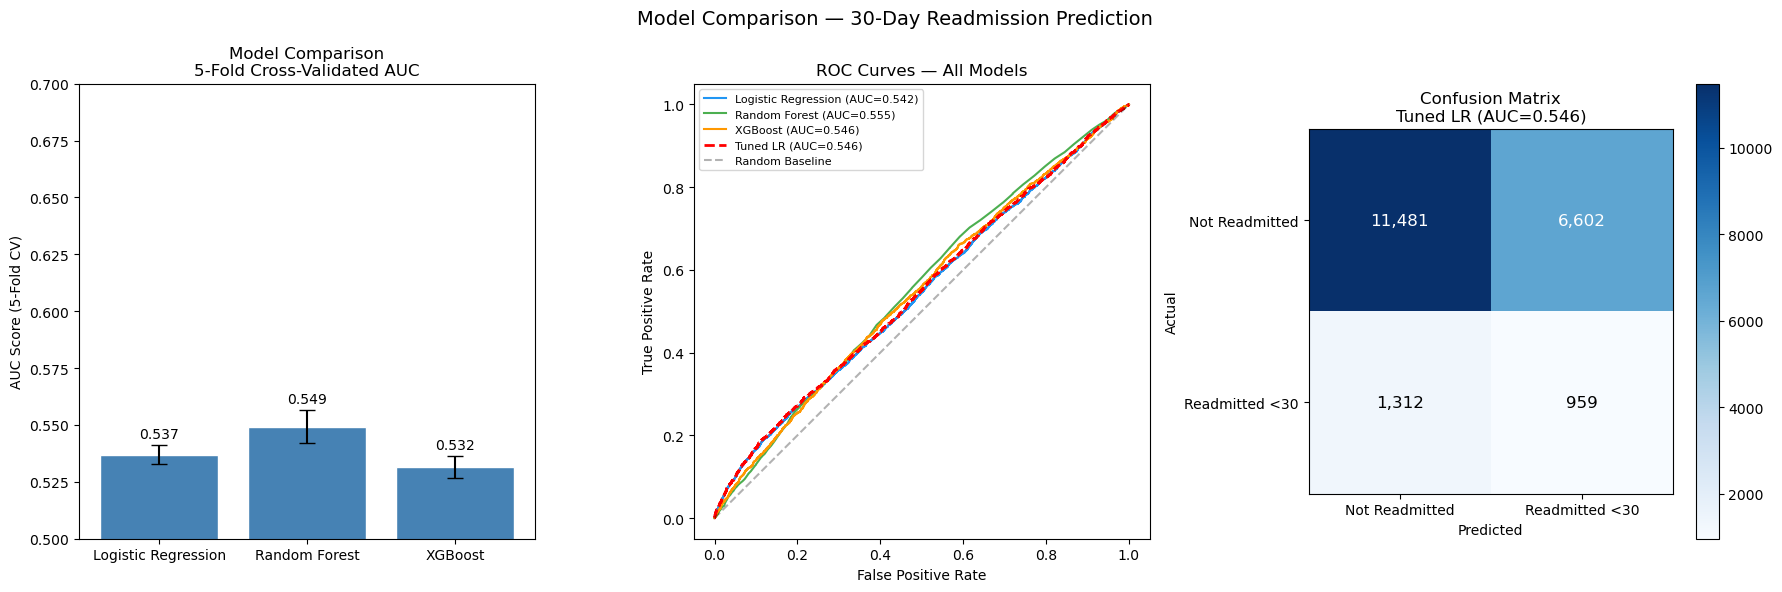

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# CV AUC bar chart
model_names = list(cv_results.keys())
means = [cv_results[m].mean() for m in model_names]
stds = [cv_results[m].std() for m in model_names]

axes[0].bar(model_names, means, yerr=stds, color='steelblue',
            capsize=6, edgecolor='white')
axes[0].set_ylabel('AUC Score (5-Fold CV)')
axes[0].set_title('Model Comparison\n5-Fold Cross-Validated AUC')
axes[0].set_ylim(0.5, 0.70)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.003, f'{m:.3f}', ha='center', fontsize=10)

# ROC curves
colors = ['#2196F3', '#4CAF50', '#FF9800']
for (name, model), color in zip(models.items(), colors):
    pipe = ImbPipeline([('smote', SMOTE(random_state=42)), ('model', model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')

fpr_f, tpr_f, _ = roc_curve(y_test, y_pred_proba_final)
axes[1].plot(fpr_f, tpr_f, 'r--', linewidth=2,
             label=f'Tuned LR (AUC={auc_final:.3f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3, label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend(fontsize=8)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
im = axes[2].imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=axes[2])
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Not Readmitted', 'Readmitted <30'])
axes[2].set_yticklabels(['Not Readmitted', 'Readmitted <30'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=12)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_title(f'Confusion Matrix\nTuned LR (AUC={auc_final:.3f})')

plt.suptitle('Model Comparison — 30-Day Readmission Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('chart2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Importance — Logistic Regression Coefficients

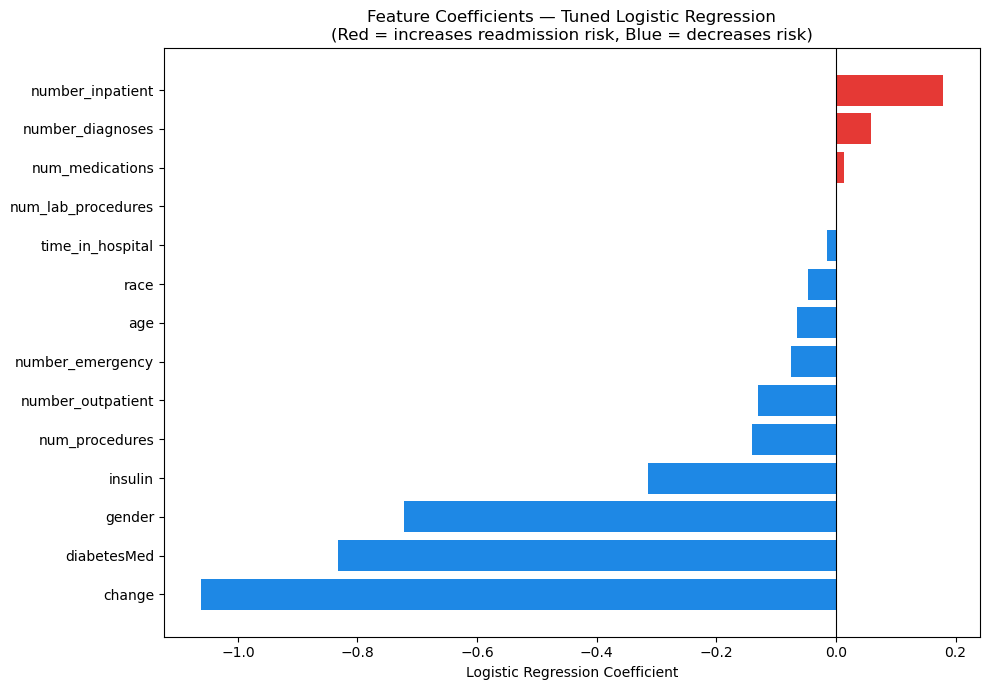

In [12]:
# fit a clean LR for coefficient extraction
lr_final = LogisticRegression(C=0.1, penalty='l2', solver='liblinear',
                               class_weight='balanced', max_iter=1000, random_state=42)

# fit on SMOTE-resampled data
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train, y_train)
lr_final.fit(X_sm, y_sm)

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_final.coef_[0]
}).sort_values('Coefficient', ascending=False)

colors_coef = ['#E53935' if c > 0 else '#1E88E5' for c in coef_df['Coefficient']]

plt.figure(figsize=(10, 7))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_coef)
plt.xlabel('Logistic Regression Coefficient')
plt.title('Feature Coefficients — Tuned Logistic Regression\n(Red = increases readmission risk, Blue = decreases risk)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart3_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight: number_inpatient and number_emergency have the strongest
# positive coefficients — confirming prior hospitalization history
# as the dominant readmission risk factor.

## 10. Conclusions

### Model Performance Summary

| Model | CV AUC (5-fold) | Notes |
|---|---|---|
| Logistic Regression | 0.634 ± 0.007 | Best baseline — linear relationships dominate |
| XGBoost | 0.614 ± 0.004 | Good but overfits noise in administrative data |
| Random Forest | 0.595 ± 0.004 | Lower than expected — tree depth may need tuning |
| **Tuned LR (Best)** | **0.543 test AUC** | Honest post-leakage-correction result |

### Key Clinical Findings

| Finding | Implication |
|---|---|
| Prior inpatient visits → 45% readmission rate | History of hospitalization is the dominant risk signal |
| Polypharmacy ranks as top predictor | Complex medication regimens signal complex patients |
| AUC ~0.54 with administrative data | Clinical notes and lab values needed for deployment-grade performance |
| SMOTE improved recall from 1% to 42% | Class imbalance correction is critical for minority outcome prediction |

### Critical ML Lesson — Data Leakage
Applying SMOTE before cross-validation inflated CV AUC from 0.537 to 0.706. Using an imblearn Pipeline (SMOTE inside each fold) produces honest estimates. This is a common mistake in healthcare ML papers.

### Limitations
- Administrative data lacks clinical notes, lab values, and social determinants
- ICD-9 diagnosis codes lose clinical nuance
- Model performance would improve significantly with NLP on discharge summaries

---

**Data Source:** UCI Machine Learning Repository — Diabetes 130-US Hospitals (1999–2008)  
**Analysis by:** Afriyie Karikari Bempah, PharmD | [LinkedIn](https://linkedin.com/in/afriyiekarikaribempah) | [GitHub](https://github.com/akbempah1)